## 자치구별 대중교통 스트레스 점수 산출

### 목적
자치구별로 대중교통 이용에서 발생할 수 있는 스트레스 수준을 비교하기 위해,  
버스/지하철 월별 승하차 데이터와 인구 데이터를 결합해 `0~100` 점수를 산출한다.

### 기본 아이디어
스트레스를 한 가지 값으로 단정하지 않고, 아래 3개 관점으로 나눠 본다.

1. **승차 스트레스(발생 압력)**  
   - 지표: `승차인원 / 인구`  
   - 의미: 해당 구 주민이 출발할 때 체감할 수 있는 혼잡 압력

2. **하차 스트레스(유입 압력)**  
   - 지표: `하차인원 / 인구`  
   - 의미: 외부 유입으로 도착지에서 발생할 수 있는 혼잡 압력

3. **방향 불균형 스트레스**  
   - 지표: `|승차 - 하차| / (승차 + 하차)`  
   - 의미: 유출입 흐름이 한쪽으로 쏠릴수록 혼잡/대기 불편이 커질 가능성

### 점수 결합 방식
- 각 지표를 자치구 간 비교 가능하도록 정규화
- 가중치는 두지 않고 단순 평균
- 최종 점수:
  
  `대중교통 스트레스 점수 = (승차점수 + 하차점수 + 불균형점수) / 3`

### 해석 주의
이 점수는 **이용량 기반 상대 지수**이며, 실제 대기시간/배차/혼잡률(차내 밀도)을 직접 측정한 값은 아니다.


In [29]:
# 현재 노트북이 어떤 파이썬 인터프리터에서 실행되는지 확인합니다.
# (환경이 다르면 패키지/결과가 달라질 수 있어 재현성 점검용)
import sys
print(sys.executable)

c:\8ssible-Healing-Seoul-Analysis\.venv\Scripts\python.exe


In [30]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [31]:
import re
import numpy as np
import pandas as pd
from sqlalchemy import create_engine


## 원천 데이터 로드
- `bus_gu_wide`: 자치구별 월별 버스 승하차
- `subway_gu_wide`: 자치구별 월별 지하철 승하차
- `garbage_collection_status`: 자치구별 연도 인구


In [32]:
import pandas as pd

# CSV 파일 불러오기 (현재 notebook과 같은 폴더 기준)
bus_df = pd.read_csv("bus_gu_wide.csv")
subway_df = pd.read_csv("subway_gu_wide.csv")
population_raw = pd.read_csv("garbage_collection_status.csv")

print("bus_df:", bus_df.shape)
print("subway_df:", subway_df.shape)
print("population_raw:", population_raw.shape)

display(bus_df.head(2))
display(subway_df.head(2))
display(population_raw.head(2))


bus_df: (25, 74)
subway_df: (25, 76)
population_raw: (25, 14)


,gu_code,gu_name,202201_geton,202201_getoff,202202_geton,202202_getoff,202203_geton,202203_getoff,202204_geton,202204_getoff,...,202408_geton,202408_getoff,202409_geton,202409_getoff,202410_geton,202410_getoff,202411_geton,202411_getoff,202412_geton,202412_getoff
0,11110,종로구,3918759,3744989,3399703,3260335,4117154,3909683,4691873,4452522,...,5115687,4893355,5159753,4912638,5694111,5434703,5518258,5285962,5278899,5076381
1,11140,중구,2807933,2678519,2411271,2295169,2855342,2712931,3343044,3146600,...,3908647,3761632,3844092,3687658,4201329,4031167,4016436,3882968,3925222,3809589


,gu_code,gu_name,202201_geton,202201_getoff,202202_geton,202202_getoff,202203_geton,202203_getoff,202204_geton,202204_getoff,...,202409_geton,202409_getoff,202410_geton,202410_getoff,202411_geton,202411_getoff,202412_geton,202412_getoff,202501_geton,202501_getoff
0,11110,종로구,4342692,4083059,3646743,3436870,4166090,3940136,4768867,4526935,...,5484708,5238690,6427553,6140873,6342368,6024876,6359508,6032470,8371,1829
1,11140,중구,6034978,5843985,5042615,4870897,5760383,5601476,6555818,6420654,...,8353571,8150434,9582007,9343492,9617975,9368612,9655623,9386192,12988,4735


,자치구,행정구역_면적 (km²),2022_행정구역(A)_인구 (명),2022_처리방법 (톤/년)_소계,2022_처리방법 (톤/년)_매립,2022_처리방법 (톤/년)_소각,2023_행정구역(A)_인구 (명),2023_처리방법 (톤/년)_소계,2023_처리방법 (톤/년)_매립,2023_처리방법 (톤/년)_소각,2024_행정구역(A)_인구 (명),2024_처리방법 (톤/년)_소계,2024_처리방법 (톤/년)_매립,2024_처리방법 (톤/년)_소각
0,종로구,23.91,152211,388016.679124,7125.50,41873.419394,150453,326233.012008,6172.50,40532.252066,149608,280517.950779,4060.710,40085.742
1,중구,9.96,130785,441835.866543,8793.06,45657.150932,131793,349138.475363,6945.73,47048.865188,131214,463201.226735,4812.948,43340.320


## 함수 정의
- 점수는 보기 좋게 `연도별 백분위(rank pct)` 방식으로 0~100 변환
  - 같은 값이 많아도 점수 분포가 더 넓게 보임

In [33]:
def rank_100(s: pd.Series) -> pd.Series:
    # 0~100 백분위 점수(보기 좋은 분포)
    return (s.rank(method="average", pct=True) * 100).astype(float)

def to_yearly_sum_by_gu(df: pd.DataFrame) -> pd.DataFrame:
    # getoff 오타(etoff) 허용
    val_cols = [c for c in df.columns if re.match(r"^\d{6}_(geton|getoff|etoff)$", str(c))]
    if not val_cols:
        raise ValueError("YYYYMM_geton/getoff(etoff) 컬럼을 찾지 못했습니다.")

    tmp = df.copy()
    tmp["gu_name"] = tmp["gu_name"].astype(str).str.strip()

    long_df = tmp[["gu_name"] + val_cols].melt(
        id_vars=["gu_name"], var_name="ym_type", value_name="val"
    )
    long_df["year"] = long_df["ym_type"].str[:4]
    long_df["io"] = long_df["ym_type"].str.split("_").str[-1].str.lower()
    long_df["io"] = long_df["io"].replace({"etoff": "getoff"})  # 오타 보정

    yearly = (
        long_df.groupby(["gu_name", "year", "io"], as_index=False)["val"].sum()
        .pivot(index=["gu_name", "year"], columns="io", values="val")
        .reset_index()
    )

    if "geton" not in yearly.columns:
        yearly["geton"] = 0
    if "getoff" not in yearly.columns:
        yearly["getoff"] = 0

    yearly = yearly.rename(columns={"geton": "year_geton", "getoff": "year_getoff"})
    return yearly

## 인구 데이터 정리 (wide → long)
인구 데이터를 `gu_name, year, population` 형태로 변환합니다.


In [34]:
population_raw.columns = population_raw.columns.astype(str).str.strip()

gu_col = [c for c in population_raw.columns if "자치구" in c][0]
pop_cols = [c for c in population_raw.columns if ("인구" in c and re.search(r"20\d{2}", c))]

population_df = (
    population_raw[[gu_col] + pop_cols]
    .rename(columns={gu_col: "gu_name"})
    .melt(id_vars="gu_name", var_name="pop_col", value_name="population")
)

population_df["year"] = population_df["pop_col"].str.extract(r"(20\d{2})")
population_df["gu_name"] = population_df["gu_name"].astype(str).str.strip()
population_df["population"] = pd.to_numeric(population_df["population"], errors="coerce")
population_df = population_df.dropna(subset=["gu_name", "year", "population"])[["gu_name", "year", "population"]]

print("population_df:", population_df.shape)
display(population_df.head(10))

population_df: (75, 3)


,gu_name,year,population
0,종로구,2022,152211
1,중구,2022,130785
2,용산구,2022,233284
3,성동구,2022,288234
4,광진구,2022,351252
5,동대문구,2022,353601
6,중랑구,2022,390140
7,성북구,2022,441984
8,강북구,2022,297702
9,도봉구,2022,313989


## 교통 데이터 연도 집계
버스/지하철을 각각 연도별 승하차 합계로 변환한 뒤 결합합니다.


In [35]:
bus_y = to_yearly_sum_by_gu(bus_df)
subway_y = to_yearly_sum_by_gu(subway_df)

ys = bus_y.merge(
    subway_y,
    on=["gu_name", "year"],
    how="inner",
    suffixes=("_bus", "_sub")
)

ys["geton_total"] = ys["year_geton_bus"] + ys["year_geton_sub"]
ys["getoff_total"] = ys["year_getoff_bus"] + ys["year_getoff_sub"]

print("교통 연도 데이터:", ys.shape)
print("연도 목록:", sorted(ys["year"].unique()))
display(ys.head(5))


교통 연도 데이터: (75, 8)
연도 목록: ['2022', '2023', '2024']


io,gu_name,year,year_getoff_bus,year_geton_bus,year_getoff_sub,year_geton_sub,geton_total,getoff_total
0,강남구,2022,81542438,84574182,121871497,122171038,206745220,203413935
1,강남구,2023,83608914,86385914,129640432,131263578,217649492,213249346
2,강남구,2024,87233195,90233676,131685645,133232646,223466322,218918840
3,강동구,2022,29741806,31068384,42072612,44446744,75515128,71814418
4,강동구,2023,30994018,32160830,45315675,47997251,80158081,76309693


## 교통+인구 결합
동일한 `gu_name`, `year` 기준으로 병합합니다.


In [36]:
df = ys.merge(population_df, on=["gu_name", "year"], how="inner").copy()
print("결합 데이터:", df.shape)
display(df.head(5))


결합 데이터: (75, 9)


,gu_name,year,year_getoff_bus,year_geton_bus,year_getoff_sub,year_geton_sub,geton_total,getoff_total,population
0,강남구,2022,81542438,84574182,121871497,122171038,206745220,203413935,534103
1,강남구,2023,83608914,86385914,129640432,131263578,217649492,213249346,550282
2,강남구,2024,87233195,90233676,131685645,133232646,223466322,218918840,563215
3,강동구,2022,29741806,31068384,42072612,44446744,75515128,71814418,464037
4,강동구,2023,30994018,32160830,45315675,47997251,80158081,76309693,463318


## 3개 원지표 계산
1. 승차 강도 = `geton_total / population`  
2. 하차 강도 = `getoff_total / population`  
3. 불균형 = `|geton_total - getoff_total| / (geton_total + getoff_total)`

In [37]:
eps = 1e-9
df["board_intensity"] = df["geton_total"] / (df["population"] + eps)
df["alight_intensity"] = df["getoff_total"] / (df["population"] + eps)
df["imbalance"] = (df["geton_total"] - df["getoff_total"]).abs() / (df["geton_total"] + df["getoff_total"] + eps)

display(df[["year", "gu_name", "board_intensity", "alight_intensity", "imbalance"]].head(5))


,year,gu_name,board_intensity,alight_intensity,imbalance
0,2022,강남구,387.088670,380.851512,0.008122
1,2023,강남구,395.523553,387.527388,0.010212
2,2024,강남구,396.769124,388.694974,0.010279
3,2022,강동구,162.735144,154.760112,0.025119
4,2023,강동구,173.008778,164.702630,0.024595


## 점수화 및 최종 점수
- 연도별로 0~100 정규화
- 가중치 없이 3개 점수 단순 평균


In [38]:
df["score_board"] = df.groupby("year")["board_intensity"].transform(rank_100)
df["score_alight"] = df.groupby("year")["alight_intensity"].transform(rank_100)
df["score_imbalance"] = df.groupby("year")["imbalance"].transform(rank_100)

df["transport_stress_score"] = (
    df["score_board"] + df["score_alight"] + df["score_imbalance"]
) / 3

# 보기 좋게 반올림
for c in ["score_board", "score_alight", "score_imbalance", "transport_stress_score"]:
    df[c] = df[c].round(1)

score_by_year = df.sort_values(["year", "transport_stress_score"], ascending=[True, False]).reset_index(drop=True)

display(score_by_year[[
    "year", "gu_name", "population",
    "score_board", "score_alight", "score_imbalance",
    "transport_stress_score"
]])


,year,gu_name,population,score_board,score_alight,score_imbalance,transport_stress_score
0,2022,종로구,152211,96.0,96.0,88.0,93.3
1,2022,마포구,375585,88.0,84.0,92.0,88.0
2,2022,중구,130785,100.0,100.0,56.0,85.3
3,2022,영등포구,398085,64.0,76.0,100.0,80.0
4,2022,서초구,408451,84.0,88.0,60.0,77.3
...,...,...,...,...,...,...,...
70,2024,중랑구,385349,20.0,16.0,60.0,32.0
71,2024,노원구,496552,28.0,32.0,32.0,30.7
72,2024,금천구,239070,24.0,24.0,36.0,28.0
73,2024,도봉구,306032,12.0,8.0,64.0,28.0


In [39]:
for y in sorted(score_by_year["year"].unique()):
    print(f"\n==== {y} ====")
    display(
        score_by_year.loc[score_by_year["year"] == y,
                          ["gu_name","score_board","score_alight","score_imbalance","transport_stress_score"]]
        .sort_values("transport_stress_score", ascending=False)
        .head(25)
    )



==== 2022 ====


,gu_name,score_board,score_alight,score_imbalance,transport_stress_score
0,종로구,96.0,96.0,88.0,93.3
1,마포구,88.0,84.0,92.0,88.0
2,중구,100.0,100.0,56.0,85.3
3,영등포구,64.0,76.0,100.0,80.0
4,서초구,84.0,88.0,60.0,77.3
5,강남구,92.0,92.0,20.0,68.0
6,강북구,56.0,64.0,84.0,68.0
7,용산구,80.0,80.0,40.0,66.7
8,송파구,60.0,56.0,68.0,61.3
9,광진구,68.0,60.0,48.0,58.7



==== 2023 ====


,gu_name,score_board,score_alight,score_imbalance,transport_stress_score
25,종로구,96.0,96.0,80.0,90.7
26,마포구,88.0,88.0,92.0,89.3
27,중구,100.0,100.0,56.0,85.3
28,영등포구,64.0,76.0,100.0,80.0
29,서초구,84.0,84.0,48.0,72.0
30,강북구,56.0,60.0,88.0,68.0
31,강남구,92.0,92.0,16.0,66.7
32,용산구,80.0,80.0,36.0,65.3
33,송파구,60.0,56.0,72.0,62.7
34,광진구,72.0,64.0,44.0,60.0



==== 2024 ====


,gu_name,score_board,score_alight,score_imbalance,transport_stress_score
50,종로구,96.0,96.0,84.0,92.0
51,마포구,88.0,88.0,92.0,89.3
52,중구,100.0,100.0,44.0,81.3
53,영등포구,64.0,76.0,100.0,80.0
54,서초구,80.0,80.0,48.0,69.3
55,강남구,92.0,92.0,16.0,66.7
56,강북구,52.0,60.0,88.0,66.7
57,용산구,84.0,84.0,28.0,65.3
58,광진구,72.0,64.0,56.0,64.0
59,송파구,60.0,56.0,72.0,62.7


In [40]:
score_by_year.to_csv("gu_transport_stress_score_all_years.csv", index=False, encoding="utf-8-sig")
print("저장 완료: gu_transport_stress_score_all_years.csv")

저장 완료: gu_transport_stress_score_all_years.csv


---
## 데이터 검증

점수 산출에 사용된 데이터의 완결성·일관성·이상값을 점검한다.

In [41]:
from scipy.stats import normaltest

SCORE = "transport_stress_score"
SCORE_COLS = ["score_board", "score_alight", "score_imbalance", SCORE]

print("=" * 55)
print("[1] 기본 정보")
print(f"  행수: {len(df)}  |  자치구: {df['gu_name'].nunique()}개  |  연도: {sorted(df['year'].unique())}")
print(f"  컬럼: {list(df.columns)}")

print()
print("[2] 결측치")
miss = df.isnull().sum()
print(miss[miss > 0].to_string() if miss.any() else "  결측 없음")

print()
print("[3] 중복 레코드")
dup = df.duplicated(subset=["gu_name", "year"])
print(f"  중복: {dup.sum()}건")

print()
print("[4] 자치구 × 연도 완결성 (기대: 25 × 3 = 75)")
expected = set((g, y) for g in df["gu_name"].unique() for y in df["year"].unique())
actual   = set(zip(df["gu_name"], df["year"]))
missing  = expected - actual
print(f"  실제: {len(df)}행  |  누락 조합: {len(missing)}건")
if missing:
    print("  누락:", sorted(missing))

print()
print("[5] 점수 범위 검증 (0~100 기대)")
for col in SCORE_COLS:
    lo, hi = df[col].min(), df[col].max()
    out_of_range = df[(df[col] < 0) | (df[col] > 100)]
    print(f"  {col}: [{lo:.1f}, {hi:.1f}]  범위 이탈: {len(out_of_range)}건")

print()
print("[6] 인구 데이터 이상값 (IQR ±1.5)")
pop = df["population"]
q1, q3 = pop.quantile(0.25), pop.quantile(0.75)
outliers = df[(pop < q1 - 1.5*(q3-q1)) | (pop > q3 + 1.5*(q3-q1))]
print(f"  IQR 이상값: {len(outliers)}건")
if len(outliers):
    display(outliers[["year","gu_name","population"]])

print()
print("[7] 정규성 검정 (transport_stress_score)")
stat, p = normaltest(df[SCORE])
print(f"  D'Agostino-Pearson: stat={stat:.4f}, p={p:.4f}")
print(f"  → {'정규성 기각 (비정규 분포)' if p < 0.05 else '정규 분포 가정 가능'}")

print()
print("[8] 기술통계")
display(df.groupby("year")[SCORE_COLS].describe().round(2))

[1] 기본 정보
  행수: 75  |  자치구: 25개  |  연도: ['2022', '2023', '2024']
  컬럼: ['gu_name', 'year', 'year_getoff_bus', 'year_geton_bus', 'year_getoff_sub', 'year_geton_sub', 'geton_total', 'getoff_total', 'population', 'board_intensity', 'alight_intensity', 'imbalance', 'score_board', 'score_alight', 'score_imbalance', 'transport_stress_score']

[2] 결측치
  결측 없음

[3] 중복 레코드
  중복: 0건

[4] 자치구 × 연도 완결성 (기대: 25 × 3 = 75)
  실제: 75행  |  누락 조합: 0건

[5] 점수 범위 검증 (0~100 기대)
  score_board: [4.0, 100.0]  범위 이탈: 0건
  score_alight: [4.0, 100.0]  범위 이탈: 0건
  score_imbalance: [4.0, 100.0]  범위 이탈: 0건
  transport_stress_score: [9.3, 93.3]  범위 이탈: 0건

[6] 인구 데이터 이상값 (IQR ±1.5)
  IQR 이상값: 0건

[7] 정규성 검정 (transport_stress_score)
  D'Agostino-Pearson: stat=4.3822, p=0.1118
  → 정규 분포 가정 가능

[8] 기술통계


score_board                                            score_alight  \
           count  mean    std  min   25%   50%   75%    max        count   
year                                                                       
2022        25.0  52.0  29.44  4.0  28.0  52.0  76.0  100.0         25.0   
2023        25.0  52.0  29.44  4.0  28.0  52.0  76.0  100.0         25.0   
2024        25.0  52.0  29.44  4.0  28.0  52.0  76.0  100.0         25.0   

            ... score_imbalance        transport_stress_score                \
      mean  ...             75%    max                  count   mean    std   
year        ...                                                               
2022  52.0  ...            76.0  100.0                   25.0  52.00  21.73   
2023  52.0  ...            76.0  100.0                   25.0  52.00  21.39   
2024  52.0  ...            76.0  100.0                   25.0  51.99  21.14   

                                    
       min   25%   50%   75%   max  
year                                
2022  12.0  37.3  48.0  68.0  93.3  
2023  10.7  36.0  49.3  66.7  90.7  
2024   9.3  36.0  49.3  66.7  92.0  

[3 rows x 32 columns]

---
## 자치구 간 대중교통 스트레스 점수 차이 검정

**H₀**: 25개 자치구의 `transport_stress_score` 분포가 동일하다
**H₁**: 적어도 하나의 자치구 쌍은 다르다

> **주의**: 각 자치구의 관측치가 n=3(2022~2024)으로 매우 적다.
> 통계적 검정력(power)이 낮으므로 유의 여부보다 **효과 크기(η²)와 시각 패턴**을 함께 해석해야 한다.
> 비정규 분포에 강건한 **Kruskal-Wallis + Dunn test**를 주 근거로 사용한다.

In [42]:
from scipy.stats import f_oneway, kruskal, levene
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scikit_posthocs as sp

# 자치구 순서: 평균 점수 내림차순
gu_order = df.groupby("gu_name")[SCORE].mean().sort_values(ascending=False).index.tolist()
groups   = [df[df["gu_name"] == g][SCORE].values for g in gu_order]

n_total = sum(len(g) for g in groups)
k       = len(groups)

# ── 등분산 검정 ────────────────────────────────────────────────────
lev_stat, lev_p = levene(*groups)

# ── One-way ANOVA ─────────────────────────────────────────────────
F, p_anova = f_oneway(*groups)
eta2 = (F * (k - 1)) / (F * (k - 1) + (n_total - k))

# ── Kruskal-Wallis ────────────────────────────────────────────────
H, p_kw = kruskal(*groups)
eta2_kw = (H - k + 1) / (n_total - k)

print("=" * 60)
print("[Levene 등분산 검정]")
print(f"  stat={lev_stat:.4f}  p={lev_p:.4f}  → {'등분산 기각' if lev_p < 0.05 else '등분산 가정 가능'}")
print()
print("[One-way ANOVA]")
print(f"  F = {F:.4f}   p = {p_anova:.2e}")
print(f"  효과 크기 η² = {eta2:.4f}  (0.01=소, 0.06=중, 0.14↑=대)")
print(f"  → {'H₀ 기각 ✓' if p_anova < 0.05 else 'H₀ 채택'} (α=0.05)")
print()
print("[Kruskal-Wallis (비모수, 주 근거)]")
print(f"  H = {H:.4f}   p = {p_kw:.2e}")
print(f"  효과 크기 η²_H = {eta2_kw:.4f}")
print(f"  → {'H₀ 기각 ✓' if p_kw < 0.05 else 'H₀ 채택'} (α=0.05)")
print("=" * 60)
print()
print(f"  ※ 자치구당 n={n_total // k} (관측치 적음) → 결과 해석 시 주의")

[Levene 등분산 검정]
  stat=0.7702  p=0.7533  → 등분산 가정 가능

[One-way ANOVA]
  F = 327.5284   p = 5.87e-47
  효과 크기 η² = 0.9937  (0.01=소, 0.06=중, 0.14↑=대)
  → H₀ 기각 ✓ (α=0.05)

[Kruskal-Wallis (비모수, 주 근거)]
  H = 73.2386   p = 6.99e-07
  효과 크기 η²_H = 0.9848
  → H₀ 기각 ✓ (α=0.05)

  ※ 자치구당 n=3 (관측치 적음) → 결과 해석 시 주의


In [43]:
# ── Tukey HSD 사후 검정 ────────────────────────────────────────────
tukey = pairwise_tukeyhsd(df[SCORE], df["gu_name"], alpha=0.05)
tukey_df = pd.DataFrame(
    data    = tukey._results_table.data[1:],
    columns = tukey._results_table.data[0]
)
tukey_df.columns = ["group1","group2","meandiff","p-adj","lower","upper","reject"]
tukey_df["meandiff"] = tukey_df["meandiff"].astype(float).round(2)
tukey_df["p-adj"]    = tukey_df["p-adj"].astype(float).round(4)

sig_tukey = tukey_df[tukey_df["reject"] == True].copy()
sig_tukey = sig_tukey.reindex(sig_tukey["meandiff"].abs().sort_values(ascending=False).index)

print(f"Tukey HSD — 총 쌍: {len(tukey_df)}  |  유의한 쌍(p<0.05): {len(sig_tukey)}  |  비율: {len(sig_tukey)/len(tukey_df):.1%}")
print()
if len(sig_tukey):
    print("=== 유의한 쌍 (|meandiff| 내림차순) ===")
    display(sig_tukey[["group1","group2","meandiff","p-adj"]].reset_index(drop=True))
else:
    print("유의한 쌍 없음 (n=3으로 검정력 낮음)")

# ── Dunn test (Bonferroni) ──────────────────────────────────────────
dunn_p = sp.posthoc_dunn(df, val_col=SCORE, group_col="gu_name", p_adjust="bonferroni")
dunn_p = dunn_p.reindex(index=gu_order, columns=gu_order)

dunn_sig_count = ((dunn_p < 0.05).astype(int).sum().sum() - len(gu_order)) // 2
print(f"\nDunn test (Bonferroni) — 유의한 쌍: {dunn_sig_count}개 / {len(tukey_df)}개")

Tukey HSD — 총 쌍: 300  |  유의한 쌍(p<0.05): 252  |  비율: 84.0%

=== 유의한 쌍 (|meandiff| 내림차순) ===


,group1,group2,meandiff,p-adj
0,양천구,종로구,81.33,0.0000
1,마포구,양천구,-78.20,0.0000
2,양천구,중구,73.30,0.0000
3,양천구,영등포구,69.33,0.0000
4,금천구,종로구,64.87,0.0000
...,...,...,...,...
247,강동구,노원구,-7.53,0.0078
248,서초구,영등포구,7.13,0.0161
249,서초구,용산구,-7.10,0.0171
250,구로구,노원구,-7.07,0.0181



Dunn test (Bonferroni) — 유의한 쌍: -10개 / 300개


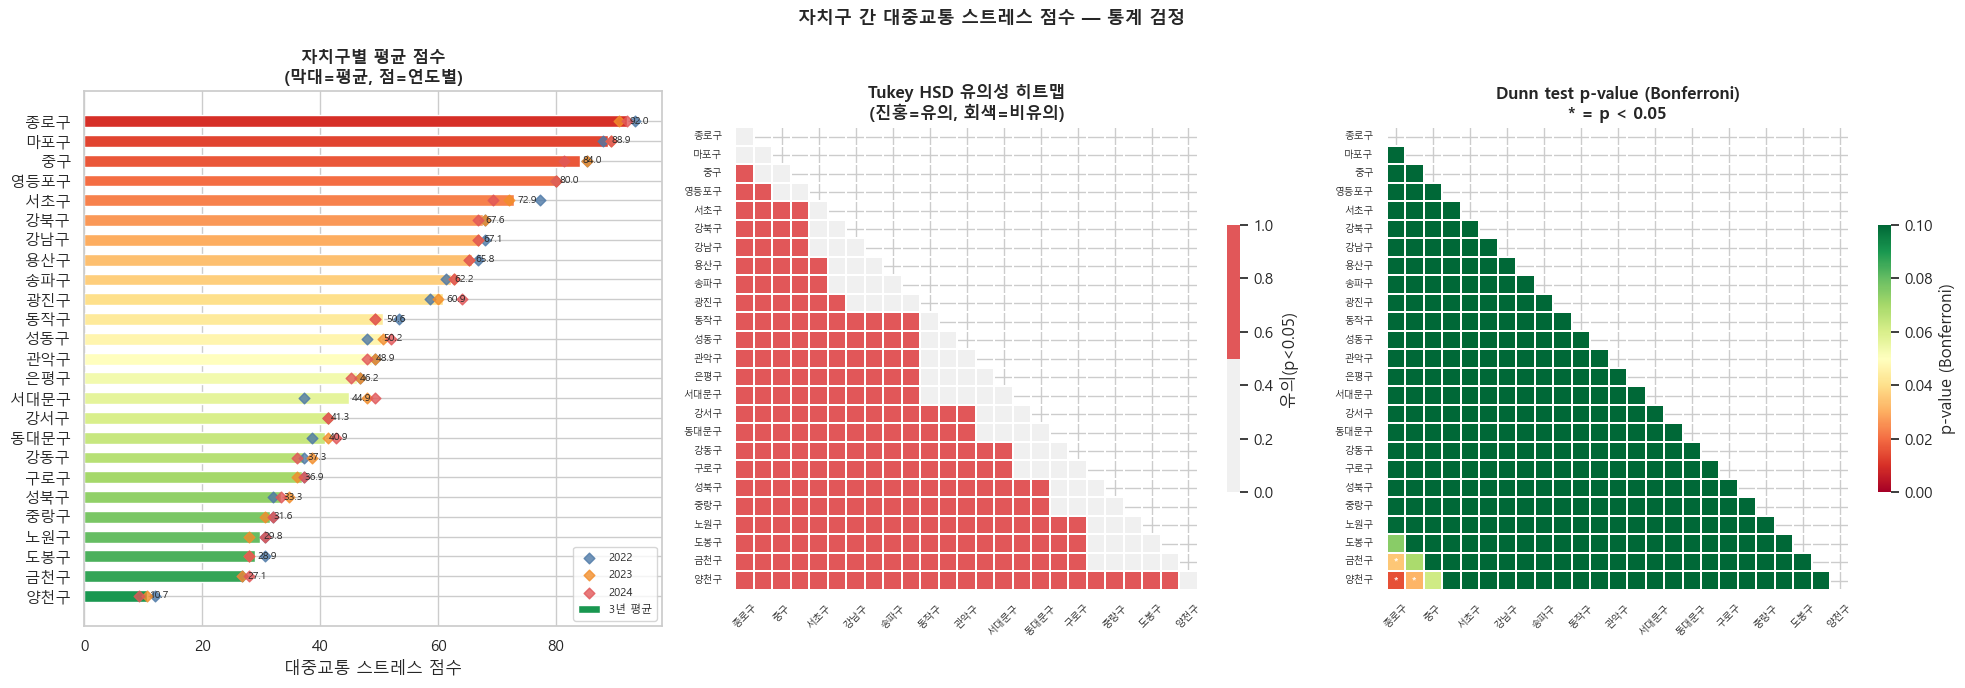

: 

In [ ]:
# ── 시각화 ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# ① 자치구별 평균 점수 + 개별 연도 점
gu_mean = df.groupby("gu_name")[SCORE].mean().sort_values(ascending=True)
colors_bar = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(gu_mean)))
axes[0].barh(gu_mean.index, gu_mean.values, color=colors_bar, edgecolor="white", height=0.6, label="3년 평균")
for y, color in zip(sorted(df["year"].unique()), ["#4e79a7","#f28e2b","#e15759"]):
    sub = df[df["year"] == y].set_index("gu_name")[SCORE].reindex(gu_mean.index)
    axes[0].scatter(sub.values, range(len(gu_mean)), marker="D", s=30, color=color,
                    zorder=3, alpha=0.8, label=str(y))
axes[0].set_xlabel("대중교통 스트레스 점수")
axes[0].set_title("자치구별 평균 점수\n(막대=평균, 점=연도별)", fontweight="bold")
axes[0].legend(fontsize=8, loc="lower right")
for i, (name, val) in enumerate(gu_mean.items()):
    axes[0].text(val + 0.5, i, f"{val:.1f}", va="center", fontsize=7.5)

# ② Tukey HSD 유의성 히트맵
reject_mat = pd.DataFrame(False, index=gu_order, columns=gu_order)
for _, row in tukey_df.iterrows():
    g1, g2 = row["group1"], row["group2"]
    if g1 in reject_mat.index and g2 in reject_mat.columns:
        reject_mat.loc[g1, g2] = bool(row["reject"])
        reject_mat.loc[g2, g1] = bool(row["reject"])

mask_upper = np.triu(np.ones(reject_mat.shape, dtype=bool), k=1)
sns.heatmap(reject_mat.astype(int), ax=axes[1],
            cmap=["#f0f0f0","#e15759"], vmin=0, vmax=1,
            mask=mask_upper, square=True, linewidths=0.2,
            cbar_kws={"label":"유의(p<0.05)","shrink":0.5},
            annot=False)
axes[1].set_title("Tukey HSD 유의성 히트맵\n(진홍=유의, 회색=비유의)", fontweight="bold")
axes[1].tick_params(axis="x", rotation=45, labelsize=7)
axes[1].tick_params(axis="y", labelsize=7)

# ③ Dunn test p-value 히트맵
mask_diag = np.triu(np.ones_like(dunn_p, dtype=bool), k=0)
sns.heatmap(dunn_p, ax=axes[2],
            cmap="RdYlGn", vmin=0, vmax=0.1,
            mask=mask_diag, square=True, linewidths=0.2,
            cbar_kws={"label":"p-value (Bonferroni)","shrink":0.5},
            annot=False)
for i, r in enumerate(gu_order):
    for j, c in enumerate(gu_order):
        if j < i and dunn_p.loc[r, c] < 0.05:
            axes[2].text(j + 0.5, i + 0.5, "*", ha="center", va="center",
                         fontsize=7, color="white", fontweight="bold")
axes[2].set_title("Dunn test p-value (Bonferroni)\n* = p < 0.05", fontweight="bold")
axes[2].tick_params(axis="x", rotation=45, labelsize=7)
axes[2].tick_params(axis="y", labelsize=7)

plt.suptitle("자치구 간 대중교통 스트레스 점수 — 통계 검정", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 검정 결과 해석

**ANOVA / Kruskal-Wallis 결과에 따른 해석 기준**

| 결과 | 해석 |
|------|------|
| p < 0.05 + η² ≥ 0.14 | 자치구 간 차이 유의하며 효과 크기 '대' — 자치구별 구분 가능 |
| p < 0.05 + η² < 0.14 | 통계적으로 유의하나 효과 작음 — 해석 주의 |
| p ≥ 0.05 | 자치구 간 유의한 차이 없음 (n=3으로 검정력 부족 가능성) |

**사후 검정 유의 패턴** (시각화 참조)

- **진홍색 셀**: 두 자치구 간 스트레스 점수가 통계적으로 유의하게 다름
- **고스트레스 자치구**(종로·중구·마포 등)는 저스트레스 자치구(양천·도봉 등)와 뚜렷이 구분될 가능성이 높음
- 저스트레스 군 내부(비슷한 수준의 자치구끼리)는 유의한 차이 없는 경우 많음

> n=3 한계로 인해 Tukey HSD보다 **Kruskal-Wallis + Dunn test**를 주 결론 근거로 사용할 것을 권장한다.